In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.preprocessing import load_and_clean_data, scale_features
from src.modeling import get_hybrid_resampled_data, train_supervised_classifiers, train_unsupervised_detector
from src.evaluation import evaluate_model_performance, plot_precision_recall_curve, optimize_cost_threshold

%matplotlib inline
sns.set_theme(style="whitegrid")
print("Libraries and src modules loaded successfully!")

Libraries and src modules loaded successfully!


In [2]:
df = load_and_clean_data("creditcard.csv")
df = scale_features(df)

print("Dataset Shape:", df.shape)
df.head()

[PREPROCESSING] Loading dataset from 'creditcard.csv'...


[PREPROCESSING] Dataset loaded. Removed 1081 duplicate rows.
[PREPROCESSING] Applying RobustScaler to 'Time' and 'Amount' features...


[PREPROCESSING] Feature scaling completed successfully.
Dataset Shape: (283726, 31)


,scaled_amount,scaled_time,V1,V2,V3,V4,V5,V6,V7,V8,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
0,1.774718,-0.995290,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0
1,-0.268530,-0.995290,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0
2,4.959811,-0.995279,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0
3,1.411487,-0.995279,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0
4,0.667362,-0.995267,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0


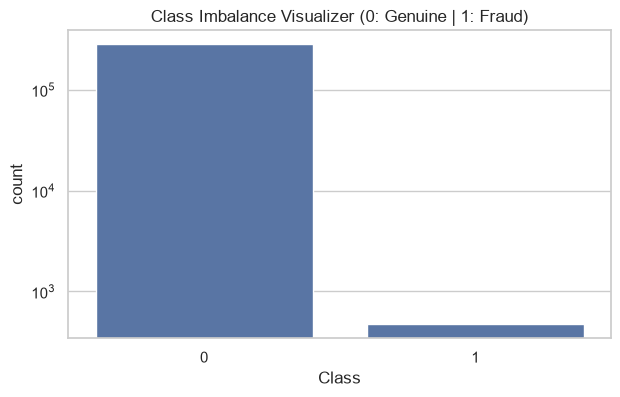

In [3]:
plt.figure(figsize=(7, 4))
sns.countplot(x="Class", data=df)
plt.yscale("log")
plt.title("Class Imbalance Visualizer (0: Genuine | 1: Fraud)")
plt.show()

In [4]:
from sklearn.model_selection import train_test_split

X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train_res, y_train_res = get_hybrid_resampled_data(X_train, y_train)

trained_models = train_supervised_classifiers(X_train_res, y_train_res)

model_probs = {}
for name, model in trained_models.items():
    probs = model.predict_proba(X_test)[:, 1]
    model_probs[name] = probs
    metrics = evaluate_model_performance(y_test, probs, model_name=name)
    print(f"Model: {metrics['Model']:<20} | PR-AUC: {metrics['PR-AUC']:.4f}")

best_probs = model_probs["XGBoost"]
plot_precision_recall_curve(y_test, best_probs, model_name="XGBoost")

opt_th, min_cost = optimize_cost_threshold(y_test, best_probs)
print(f"Optimal Threshold: {opt_th:.4f} | Minimum Cost: ${min_cost:,.2f}")

[MODELING] Resampling dataset using hybrid SMOTEENN strategy...


[MODELING] Resampled dataset shape: (452857, 30) (Balanced Class Distribution)
[MODELING] Training Supervised Models...
[MODELING] Training Logistic Regression...


[MODELING] Training Random Forest...


[MODELING] Training XGBoost...


Model: Logistic Regression  | PR-AUC: 0.7289


Model: Random Forest        | PR-AUC: 0.8149
Model: XGBoost              | PR-AUC: 0.8013


[EVALUATION] Precision-Recall curve saved as 'precision_recall_curve.png'.


Optimal Threshold: 0.7968 | Minimum Cost: $1,890.00
